<a href="https://colab.research.google.com/github/VishnuPrasaath-182006/CredGuard-Drift_Detection_Model/blob/main/CredGuard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CredGuard - Drift Detection and Risk Prediction Model**

## Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler # Standardise all the inputs
from sklearn.model_selection import train_test_split # Training and Testing the data
from sklearn.ensemble import RandomForestRegressor # RandomForsest Regressor
from xgboost import XGBRegressor # XGBoost Regressor
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score

## Loading the Dataset

In [ ]:
df = pd.read_csv('/content/german_credit_data (1).csv')

## File Handling

In [ ]:
df.columns

Index(['S.No', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')

In [ ]:
df.shape

(1000, 10)

In [ ]:
df.head(10)

,S.No,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
5,5,35,male,1,free,NaN,NaN,9055,36,education
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment
7,7,35,male,3,rent,little,moderate,6948,36,car
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV
9,9,28,male,3,own,little,moderate,5234,30,car


In [ ]:
df.tail(10)

,S.No,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
990,990,37,male,1,own,NaN,NaN,3565,12,education
991,991,34,male,1,own,moderate,NaN,1569,15,radio/TV
992,992,23,male,1,rent,NaN,little,1936,18,radio/TV
993,993,30,male,3,own,little,little,3959,36,furniture/equipment
994,994,50,male,2,own,NaN,NaN,2390,12,car
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV
999,999,27,male,2,own,moderate,moderate,4576,45,car


## Check null values - **Saving account, Checking amount** are null

In [ ]:
df.isnull().sum()

,0
S.No,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   S.No              1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


## Handling Missing values for a specific column

In [ ]:
df['Saving accounts'] = df['Saving accounts'].fillna(df['Saving accounts'].mode()[0])
df['Checking account'] = df['Checking account'].fillna(df['Checking account'].mode()[0])

In [ ]:
df.isnull().sum()

,0
S.No,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


In [ ]:
df.head(10)

,S.No,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,little,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,little,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
5,5,35,male,1,free,little,little,9055,36,education
6,6,53,male,2,own,quite rich,little,2835,24,furniture/equipment
7,7,35,male,3,rent,little,moderate,6948,36,car
8,8,61,male,1,own,rich,little,3059,12,radio/TV
9,9,28,male,3,own,little,moderate,5234,30,car


In [ ]:
df.tail(10)

,S.No,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
990,990,37,male,1,own,little,little,3565,12,education
991,991,34,male,1,own,moderate,little,1569,15,radio/TV
992,992,23,male,1,rent,little,little,1936,18,radio/TV
993,993,30,male,3,own,little,little,3959,36,furniture/equipment
994,994,50,male,2,own,little,little,2390,12,car
995,995,31,female,1,own,little,little,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,little,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV
999,999,27,male,2,own,moderate,moderate,4576,45,car


## Data Summarization

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   S.No              1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   1000 non-null   object
 6   Checking account  1000 non-null   object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [ ]:
df.describe()

,S.No,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


## Define **Features and Target**

In [ ]:
x = df.drop('Credit amount', axis=1)
y = df['Credit amount']

In [ ]:
x = pd.get_dummies(df, drop_first=True)

## **Training and Testing** the model

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

## Standardise all the inputs

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

## RandomForest Regression

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

## XGBoost Regressor

In [ ]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

## Evaluating the model

In [ ]:
def evaluate(y_test, y_pred, model_name):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"{model_name}")
    print("R2 Score :", r2)
    print("RMSE     :", rmse)
    print("-" * 30)
print("The model values are:-")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")

The model values are:-
Random Forest
R2 Score : 0.9997585549477318
RMSE     : 38.32690003117907
------------------------------
XGBoost
R2 Score : 0.9983289837837219
RMSE     : 100.82950395190636
------------------------------


## Simulating Data Drift in Production Environment

In [ ]:
X_production = x_test.copy()

# Simulate economic change
X_production['Credit amount'] *= 1.3   # increase loans
X_production['Duration'] *= 1.2        # longer repayment

# Add noise
X_production += np.random.normal(0, 0.5, X_production.shape)

## Risk Prediction and Drift Analysis System

In [ ]:
def risk_and_drift_analysis(models, X_train, X_prod, scaler=None, y_prod=None):
    # Ensure correct format
    X_prod = pd.DataFrame(X_prod, columns=X_train.columns)

    # -----------------------------
    # 1. PREDICTION
    # -----------------------------
    print("\n===== RISK PREDICTION =====")

    results = predict_risk(models, X_prod, scaler, feature_names=X_train.columns)

    for name, res in results.items():
        avg_risk = res['risk_probability'].mean()

        print(f"\n{name}")
        print(f"Average Risk Score: {avg_risk:.3f}")

        # Risk category
        if avg_risk > 0.7:
            print("Risk Level: HIGH")
        elif avg_risk > 0.4:
            print("Risk Level: MEDIUM")
        else:
            print("Risk Level: LOW")

    # -----------------------------
    # 2. DRIFT DETECTION
    # -----------------------------
    print("\n===== DRIFT ANALYSIS =====")

    drift_report = detect_drift(X_train, X_prod)

    drifted_features = []

    for col, val in drift_report.items():
        if val['drift_detected']:
            drifted_features.append(col)
            print(f"{col} → Drift (p={val['p_value']:.4f})")

    drift_percentage = (len(drifted_features) / len(X_train.columns)) * 100

    print(f"\nTotal Drifted Features: {len(drifted_features)}")
    print(f"Drift Percentage: {drift_percentage:.2f}%")

    # -----------------------------
    # 3. IMPACT ANALYSIS
    # -----------------------------
    print("\n===== IMPACT ANALYSIS =====")

    if drift_percentage > 30:
        print("⚠️ Significant drift detected → Model reliability LOW")
    elif drift_percentage > 10:
        print("⚠️ Moderate drift → Monitor closely")
    else:
        print("✅ Low drift → Model stable")

    # -----------------------------
    # 4. PERFORMANCE DRIFT (if labels available)
    # -----------------------------
    if y_prod is not None:
        print("\n===== PERFORMANCE CHECK =====")

        for name, model in models.items():
            perf = performance_drift(model, X_train, y_train, X_prod, y_prod)

            print(f"\n{name}")
            print(f"Train Acc: {perf['train_acc']:.3f}")
            print(f"Prod Acc: {perf['prod_acc']:.3f}")
            print(f"Drop: {perf['performance_drop']:.3f}")

    return results, drifted_features

In [ ]:
models = {
    'Random Forest': rf,
    'XGBoost': xgb}

## Running the Risk and Drift Analysis Model

In [ ]:
results, drifted = risk_and_drift_analysis(
    models,
    x_train,
    X_production,
    scaler
)


===== RISK PREDICTION =====

Random Forest
Average Risk Score: 320.960
Risk Level: HIGH

XGBoost
Average Risk Score: 344.533
Risk Level: HIGH

===== DRIFT ANALYSIS =====
Job → Drift (p=0.0000)
Credit amount → Drift (p=0.0189)
Duration → Drift (p=0.0002)
Sex_male → Drift (p=0.0000)
Housing_own → Drift (p=0.0000)
Housing_rent → Drift (p=0.0000)
Saving accounts_moderate → Drift (p=0.0000)
Saving accounts_quite rich → Drift (p=0.0000)
Saving accounts_rich → Drift (p=0.0000)
Checking account_moderate → Drift (p=0.0000)
Checking account_rich → Drift (p=0.0000)
Purpose_car → Drift (p=0.0000)
Purpose_domestic appliances → Drift (p=0.0000)
Purpose_education → Drift (p=0.0000)
Purpose_furniture/equipment → Drift (p=0.0000)
Purpose_radio/TV → Drift (p=0.0000)
Purpose_repairs → Drift (p=0.0000)
Purpose_vacation/others → Drift (p=0.0000)

Total Drifted Features: 18
Drift Percentage: 90.00%

===== IMPACT ANALYSIS =====
⚠️ Significant drift detected → Model reliability LOW


## Data Visualisation

### Correlation Matrix

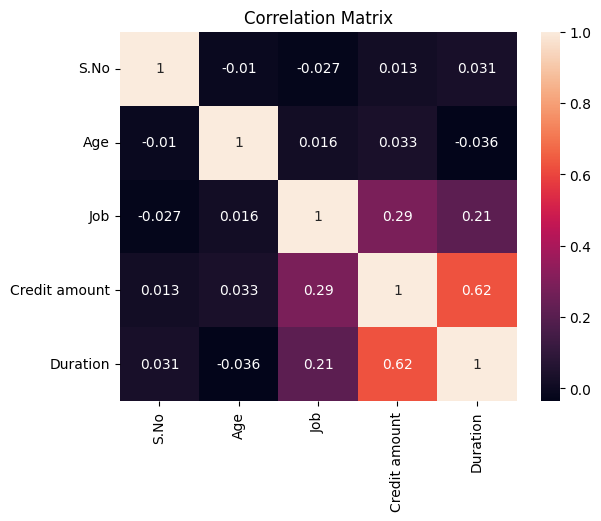

In [ ]:
plt.figure()

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

# **CountPlot** - to Compare the value between columns

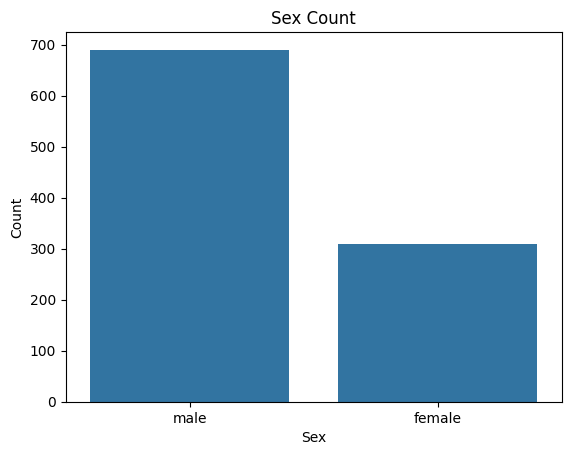

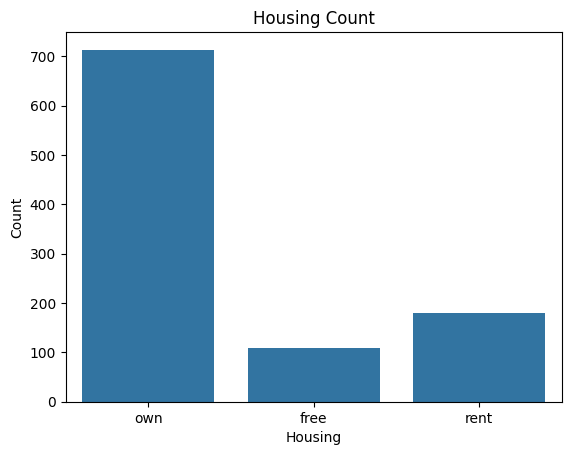

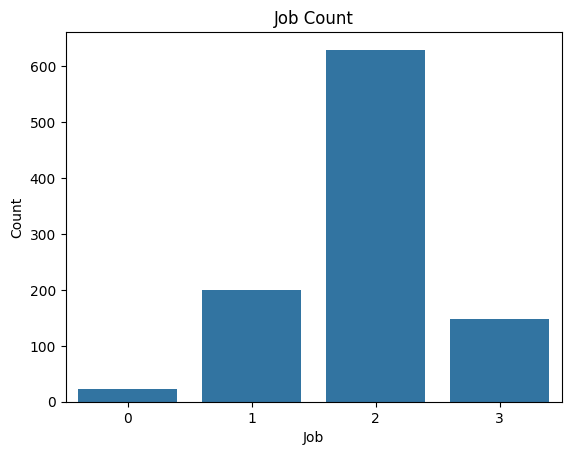

In [ ]:
cat_cols = ['Sex', 'Housing','Job']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"{col} Count")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### **Histogram** - for evaluating the Age Distribution

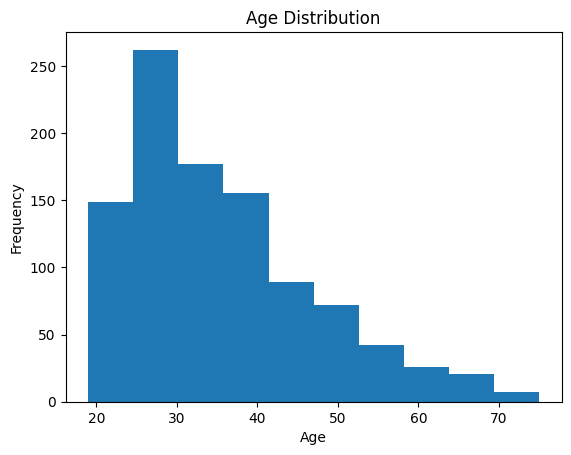

In [ ]:
plt.figure()

plt.hist(df['Age'], bins=10)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')

plt.show()

### Model evaluation by using **R_2 score and MSE**

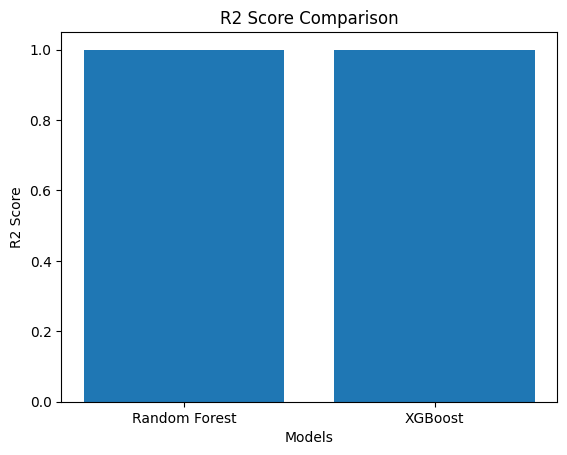

In [ ]:
model = ['Random Forest', 'XGBoost']

r2_scores = [
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_xgb)
]

plt.figure()
plt.bar(model, r2_scores)
plt.title("R2 Score Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

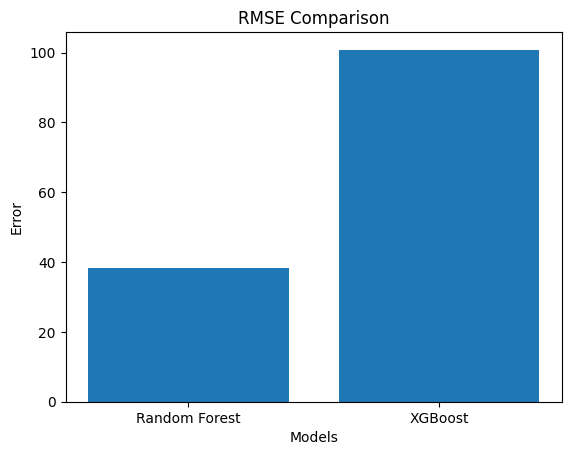

In [ ]:
from sklearn.metrics import mean_squared_error

rmse = [
    np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    np.sqrt(mean_squared_error(y_test, y_pred_xgb))
]

plt.figure()
plt.bar(model, rmse)
plt.title("RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("Error")
plt.show()

### From the above graph we can conclude that the **RandomForest** is better than **XGBoost** because the **RMSE is lower** for **RandomForest**

### If the value is less in **RMSE(Root Mean Sqaured Error)** then the model is better so **RandomForst** is better than **XGBoost**